In [1]:
!nvidia-smi

Wed Aug 23 10:14:43 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P8     9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [5]:
# # # Intstall library and softwares
# !pip install transformers datasets sacremoses &> /dev/null
# !pip install timm &> /dev/null
# !apt install poppler-utils &> /dev/null
# !pip install pdf2image tqdm &> /dev/null
# !pip install easyocr &> /dev/null
# !pip install opencv-python==4.5.5.64 > /dev/null
!pip install paddlepaddle
# !pip install img2table[paddle] > /dev/null

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# All Imports
from pdf2image import convert_from_path
import torch
import numpy as np
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import PIL
from img2table.ocr import PaddleOCR
import easyocr
import csv


ImportError: ignored

There are several fine tuned huggingface models to detect tables from images. There are a list of them
1. TahaDouaji/detr-doc-table-detection
2. Benito/DeTr-TableDetection-5000-images


In [ ]:
def load_model():
  preprocessor_url = "microsoft/table-transformer-detection"
  image_processor = AutoImageProcessor.from_pretrained(preprocessor_url)
  model_url = 'Benito/DeTr-TableDetection-5000-images'
  model = AutoModelForObjectDetection.from_pretrained(model_url)
  return image_processor, model

def convert_pdf_to_img(url):
  images = convert_from_path(url)
  return images

def detect_tables(images, model, preprocessor):
  inputs = preprocessor(images=images, return_tensors="pt")
  outputs = model(**inputs)
  target_sizes = torch.tensor( [img.size[::-1] for img in images])
  results = preprocessor.post_process_object_detection(outputs, threshold=0.8, target_sizes=target_sizes)
  for i in  range(len(results)):
    pageResult = results[i]
    for score, label, box in zip(pageResult["scores"], pageResult["labels"], pageResult["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        print(
            f"Page No {i+1} Detected {model.config.id2label[label.item()]} with confidence "
            f"{round(score.item(), 3)} at location {box}"
        )
  return results

def apply_results_on_images(images, results):
  extractedTables = []
  for i in range(len(results)):
    for box in results[i]['boxes']:
      obj = {
          'index': i,
          'img': images[i]
      }
      obj['extracted'] = PIL.Image.fromarray(np.array(images[i])[int(box[1]):int(box[3]), int(box[0]):int(box[2])])
      obj['box'] = ( (int(box[0]), int(box[1])), (int(box[2]), int(box[3])) )
      extractedTables.append(obj)
  return extractedTables

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.


Page No 1 Detected table with confidence 0.822 at location [53.35, 243.53, 1804.9, 1242.87]


In [ ]:
"""
    Algorithm:
    1. Identify the table bounds ( Top and Bottom ) on the extracted table
    2. Using the Top and Bottom bound, count the ocr elements and try to detect potential columns
    3. Detect the alignment of the each column
    4. As per the alignment of the column, draw the lines
"""

def detect_rows(bounds, size):
    cols = {}
    rows = {}
    for bound in bounds:
        p0, p1, p2, p3 = bound[0]
        row_height = p2[1] - p0[1]
        row_mid = (p0[1] + p2[1])//2
        for mid in rows:
          r1, r2 = rows[mid]['span']
          if row_mid > r1 and row_mid < r2:
              row_mid = mid
        try:
            rows[row_mid]['count'] += 1
            rows[row_mid]['ocr'].append(bound)
            if rows[row_mid]['span'][0] > p0[1]:
                rows[row_mid]['span'][0] = p0[1]
            if rows[row_mid]['span'][1] < p2[1]:
                rows[row_mid]['span'][1] = p2[1]
            rows[row_mid]['height'] = rows[row_mid]['span'][1] - rows[row_mid]['span'][0]
        except Exception as e:
            rows[row_mid] = { 'count': 1, 'span': [p0[1], p2[1]], 'height': row_height, 'ocr': [bound] }

    max_row_val_count = 0
    avg_row_val_count = 0
    for row in rows:
        l = rows[row]['count']
        if l > max_row_val_count:
            max_row_val_count = l
        avg_row_val_count += l
    avg_row_val_count = avg_row_val_count // len(rows)

    tolerance = avg_row_val_count * 0
    final_rows = {**rows}
    for row in rows:
        if rows[row]['count'] < tolerance:
            del(final_rows[row])

    rows = final_rows
    tableTop = size[1];
    tableBottom = 0;
    rowLines = []
    rowMidLines = [mid for mid in rows]
    rowMidLines.sort()
    for i in range(len(rowMidLines) - 1):
      mid, nextMid = rowMidLines[i], rowMidLines[i+1]
      # rowLines.append( (rows[mid]['span'][1] + rows[nextMid]['span'][0])/2 )
      rowLines.append(rows[mid]['span'][0])
      rowLines.append(rows[nextMid]['span'][0])

      if tableTop > rows[mid]['span'][0]:
        tableTop = rows[mid]['span'][0]
      if tableBottom < rows[nextMid]['span'][1]:
        tableBottom = rows[nextMid]['span'][1]

    return (final_rows, rowLines, (tableTop, tableBottom))


def detect_cols(bounds, horizontal_bound):
    cols = {}
    for bound in bounds[::-1]:
        p0, p1, p2, p3 = bound[0]
        if p1[1] < horizontal_bound[0] or p2[1] > horizontal_bound[1]:
          # print(p1[1] , horizontal_bound[0], p2[1] , horizontal_bound[1])
          continue
        col_width = p2[0] - p0[0]
        col_mid = (p0[0] + p2[0])//2
        actual_mid = col_mid
        for mid in cols:
            r1, r2 = cols[mid]['span']
            if col_mid > r1 and col_mid < r2:
                col_mid = mid
        try:
            cols[col_mid]['count'] += 1
            cols[col_mid]['left'] += p0[0]
            cols[col_mid]['right'] += p2[0]
            cols[col_mid]['mid'] += actual_mid
            if cols[col_mid]['span'][0] > p0[0]:
                cols[col_mid]['span'][0] = p0[0]
            if cols[col_mid]['span'][1] < p2[0]:
                cols[col_mid]['span'][1] = p2[0]
            cols[col_mid]['width'] = cols[col_mid]['span'][1] - cols[col_mid]['span'][0]
        except:
            cols[col_mid] = { 'width': col_width, 'span': [p0[0], p2[0]], 'count': 1, 'mid': actual_mid, 'left': p0[0], 'right': p2[0] }

    temp_cols = {**cols}

    max_col_val_count = 0
    avg_col_val_count = 0
    for col in cols:
        l = cols[col]['count']
        if l > max_col_val_count:
            max_col_val_count = l
        avg_col_val_count += l
    avg_col_val_count = avg_col_val_count // len(cols)
    # print(max_col_val_count, avg_col_val_count)
    final_cols = {**cols}
    tolerance = avg_col_val_count * 0.75
    for col in cols:
        if cols[col]['count'] < tolerance:
            del(final_cols[col])

    cols = final_cols

    # detect alignment
    for mid in cols:
        avg_mid, avgLeft, avgRight = cols[mid]['mid'] // cols[mid]['count'], cols[mid]['left'] // cols[mid]['count'], cols[mid]['right'] // cols[mid]['count']
        leftSpan, rightSpan = cols[mid]['span']
        tolerance = cols[mid]['width'] * 0.1
        if abs(avgLeft - leftSpan) <= tolerance:
            cols[mid]['alignment'] = 'left'
        elif abs(avgRight - rightSpan) <= tolerance:
            cols[mid]['alignment'] = 'right'
        else:
            cols[mid]['alignment'] = 'mid'
        if cols[mid]['alignment'] == 'mid':
            # print(avgLeft, avgRight, leftSpan, rightSpan, tolerance)
            pass

    colLines = []
    colMidPos = [mid for mid in cols]
    colMidPos.sort()
    for i in range(len(colMidPos) - 1):
        mid, nextMid = colMidPos[i], colMidPos[i+1]
        # colLines.append( (cols[mid]['span'][1] + cols[nextMid]['span'][0])/2 )
        free_space = cols[nextMid]['span'][0] - cols[mid]['span'][1]
        if free_space > 0:
          colLines.append(cols[mid]['span'][1]+ free_space/6)
          colLines.append(cols[nextMid]['span'][0] - free_space/6)
        else:
          colLines.append( cols[mid]['span'][1] )
          colLines.append( cols[nextMid]['span'][0] )


    return (cols, colLines)



def detect_row_col_boundary(bounds, img):
  rows = detect_rows(bounds, img.size)
  cols = detect_cols(bounds, rows[2])

  colLines = [0, *cols[1], img.size[0]]
  colBoxes = []
  for i in range(len(colLines)-1):
    x1, x2 = colLines[i], colLines[i+1]
    colBoxes.append([[x1, rows[2][0], x2, img.size[1]], 1])

  rowLines = [rows[2][0], *rows[1], rows[2][1]]
  rowBoxes = []
  for i in range(len(rowLines)-1):
    y1, y2 = rowLines[i], rowLines[i+1]
    if y1 == y2:
      continue
    rowBoxes.append([[0, y1, img.size[0], y2], 1])

  return rowBoxes, colBoxes

def draw_rows_and_cols(extraction, rowcolor='red', colcolor='blue', width=2):
    image = extraction['extracted']
    draw = PIL.ImageDraw.Draw(image)
    for bound in extraction['rows']: # iterate though all the tuples of output
        x1,y1,x2,y2 = bound[0]
        p0, p1, p2, p3 = (x1,y1), (x1,y2), (x2,y2), (x2,y1) # get coordinates
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=rowcolor, width=width)
    for bound in extraction['cols']: # iterate though all the tuples of output
        x1,y1,x2,y2 = bound[0]
        p0, p1, p2, p3 = (x1,y1), (x1,y2), (x2,y2), (x2,y1) # get coordinates
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=colcolor, width=width)
    return image

In [ ]:
def perform_ocr(result, ocr='paddle'):
  img = result['extracted']
  bounds = []

  if ocr == 'easyocr':
    easyOCR = easyocr.Reader(['en'])
    bounds = easyOCR.readtext(np.array(img), detail=1)
  else:
    paddleOCR = PaddleOCR(lang="en")
    bounds = paddleOCR.hocr(np.array(img))
    bounds = [ (b[0], *b[1]) for b in bounds ]
  result['extract_bounds'] = bounds;
  result['img_bounds'] = get_full_image_bounds(result, bounds)
  return result

def get_full_image_bound(result, bound):
  new_box = []
  for i in range(len(bound[0])):
    p = [bound[0][i][0] + result['box'][0][0], bound[0][i][1] + result['box'][0][1]]
    new_box.append(p)
  return (new_box, bound[1], bound[2])

def get_full_image_bounds(result, bounds):
  full_image_bounds = []
  for bound in bounds:
    full_image_bounds.append(get_full_image_bound(result, bound))
  return full_image_bounds

def draw_boxes(image, bounds, color='yellow', width=2):
    draw = PIL.ImageDraw.Draw(image)
    for bound in bounds: # iterate though all the tuples of output
        p0, p1, p2, p3 = bound[0] # get coordinates
        draw.line([*p0, *p1, *p2, *p3, *p0], fill=color, width=width)
    return image

In [ ]:
def get_table_structure_detector(data):
  rowLinePos = [*[r[0][1] for r in data['rows']], data['rows'][-1][0][3]]
  colLinePos = [data['cols'][0][0][0], *[c[0][2] for c in data['cols']]]
  table = [ [ '' for j in range(len(colLinePos)-1) ] for i in range(len(rowLinePos)-1) ]
  table_structure = []

  for bound in data['extract_bounds']:
    p0, p1, p2, p3 = bound[0]
    rowStart, rowEnd = -1, -1
    colStart, colEnd = -1, -1
    for i in range(len(rowLinePos)-1):
      if p0[1] < rowLinePos[i+1]:
        rowStart = i;
        break
    for i in range(len(colLinePos)-1):
      if p0[0] < colLinePos[i+1]:
        colStart = i;
        break
    table[rowStart][colStart] = bound[1]

  # Remove blank cols
  blankCols = {}
  for i in range(len(colLinePos)-1):
    isBlank = True
    for r in table:
      if r[i] != '':
        isBlank = False
        break

    blankCols[i] = isBlank
  final_table = []
  for r in table:
    newR = []
    for i in range(len(r)):
      if not blankCols[i]:
        newR.append(r[i])
    final_table.append(newR)

  return table


In [ ]:
preprocessor, model = load_model()

In [ ]:
pdf_dir = "/content/drive/MyDrive/Inveniam/AI Assist/sample_outputs/Sample Tax Statement"
pdf_path = f"{pdf_dir}/input.pdf"
# pdf_path = '/content/Rent Roll Sample Asset 789.pdf'
# pdf_path = '/content/Rent Roll Sample Asset 123.pdf'
test_images = convert_pdf_to_img(pdf_path)
results = detect_tables(test_images, model, preprocessor)
extracted_tables = apply_results_on_images(test_images, results)

Page No 1 Detected table with confidence 0.86 at location [40.19, 173.04, 1671.25, 1260.51]
Page No 2 Detected table with confidence 0.941 at location [43.66, 1495.42, 1602.54, 1682.96]


In [ ]:
for ext_table in extracted_tables:
  print("Extracting table from page no", ext_table['index'] + 1 )
  updated_ext_table = perform_ocr(ext_table)
  updated_ext_table['rows'], updated_ext_table['cols'] = detect_row_col_boundary(updated_ext_table['extract_bounds'], updated_ext_table['extracted'])
  updated_ext_table['table'] = get_table_structure_detector(updated_ext_table)


Extracting table from page no 1
Extracting table from page no 2


In [ ]:
output_dir = pdf_dir
i = 0
for table in extracted_tables:
  i+=1
  filename = f"{output_dir}/output_{table['index']+1}-{i}.csv"
  print('file locaiton: ', filename)
  with open(filename, 'w', encoding='UTF8') as f:
      writer = csv.writer(f)
      for r in table['table']:
          writer.writerow(r)

file locaiton:  /content/drive/MyDrive/Inveniam/AI Assist/sample_outputs/Sample Tax Statement/output_1-1.csv
file locaiton:  /content/drive/MyDrive/Inveniam/AI Assist/sample_outputs/Sample Tax Statement/output_2-2.csv


In [ ]:
result = perform_ocr(extracted_tables[0])
img = draw_boxes(result['img'], result['img_bounds'])

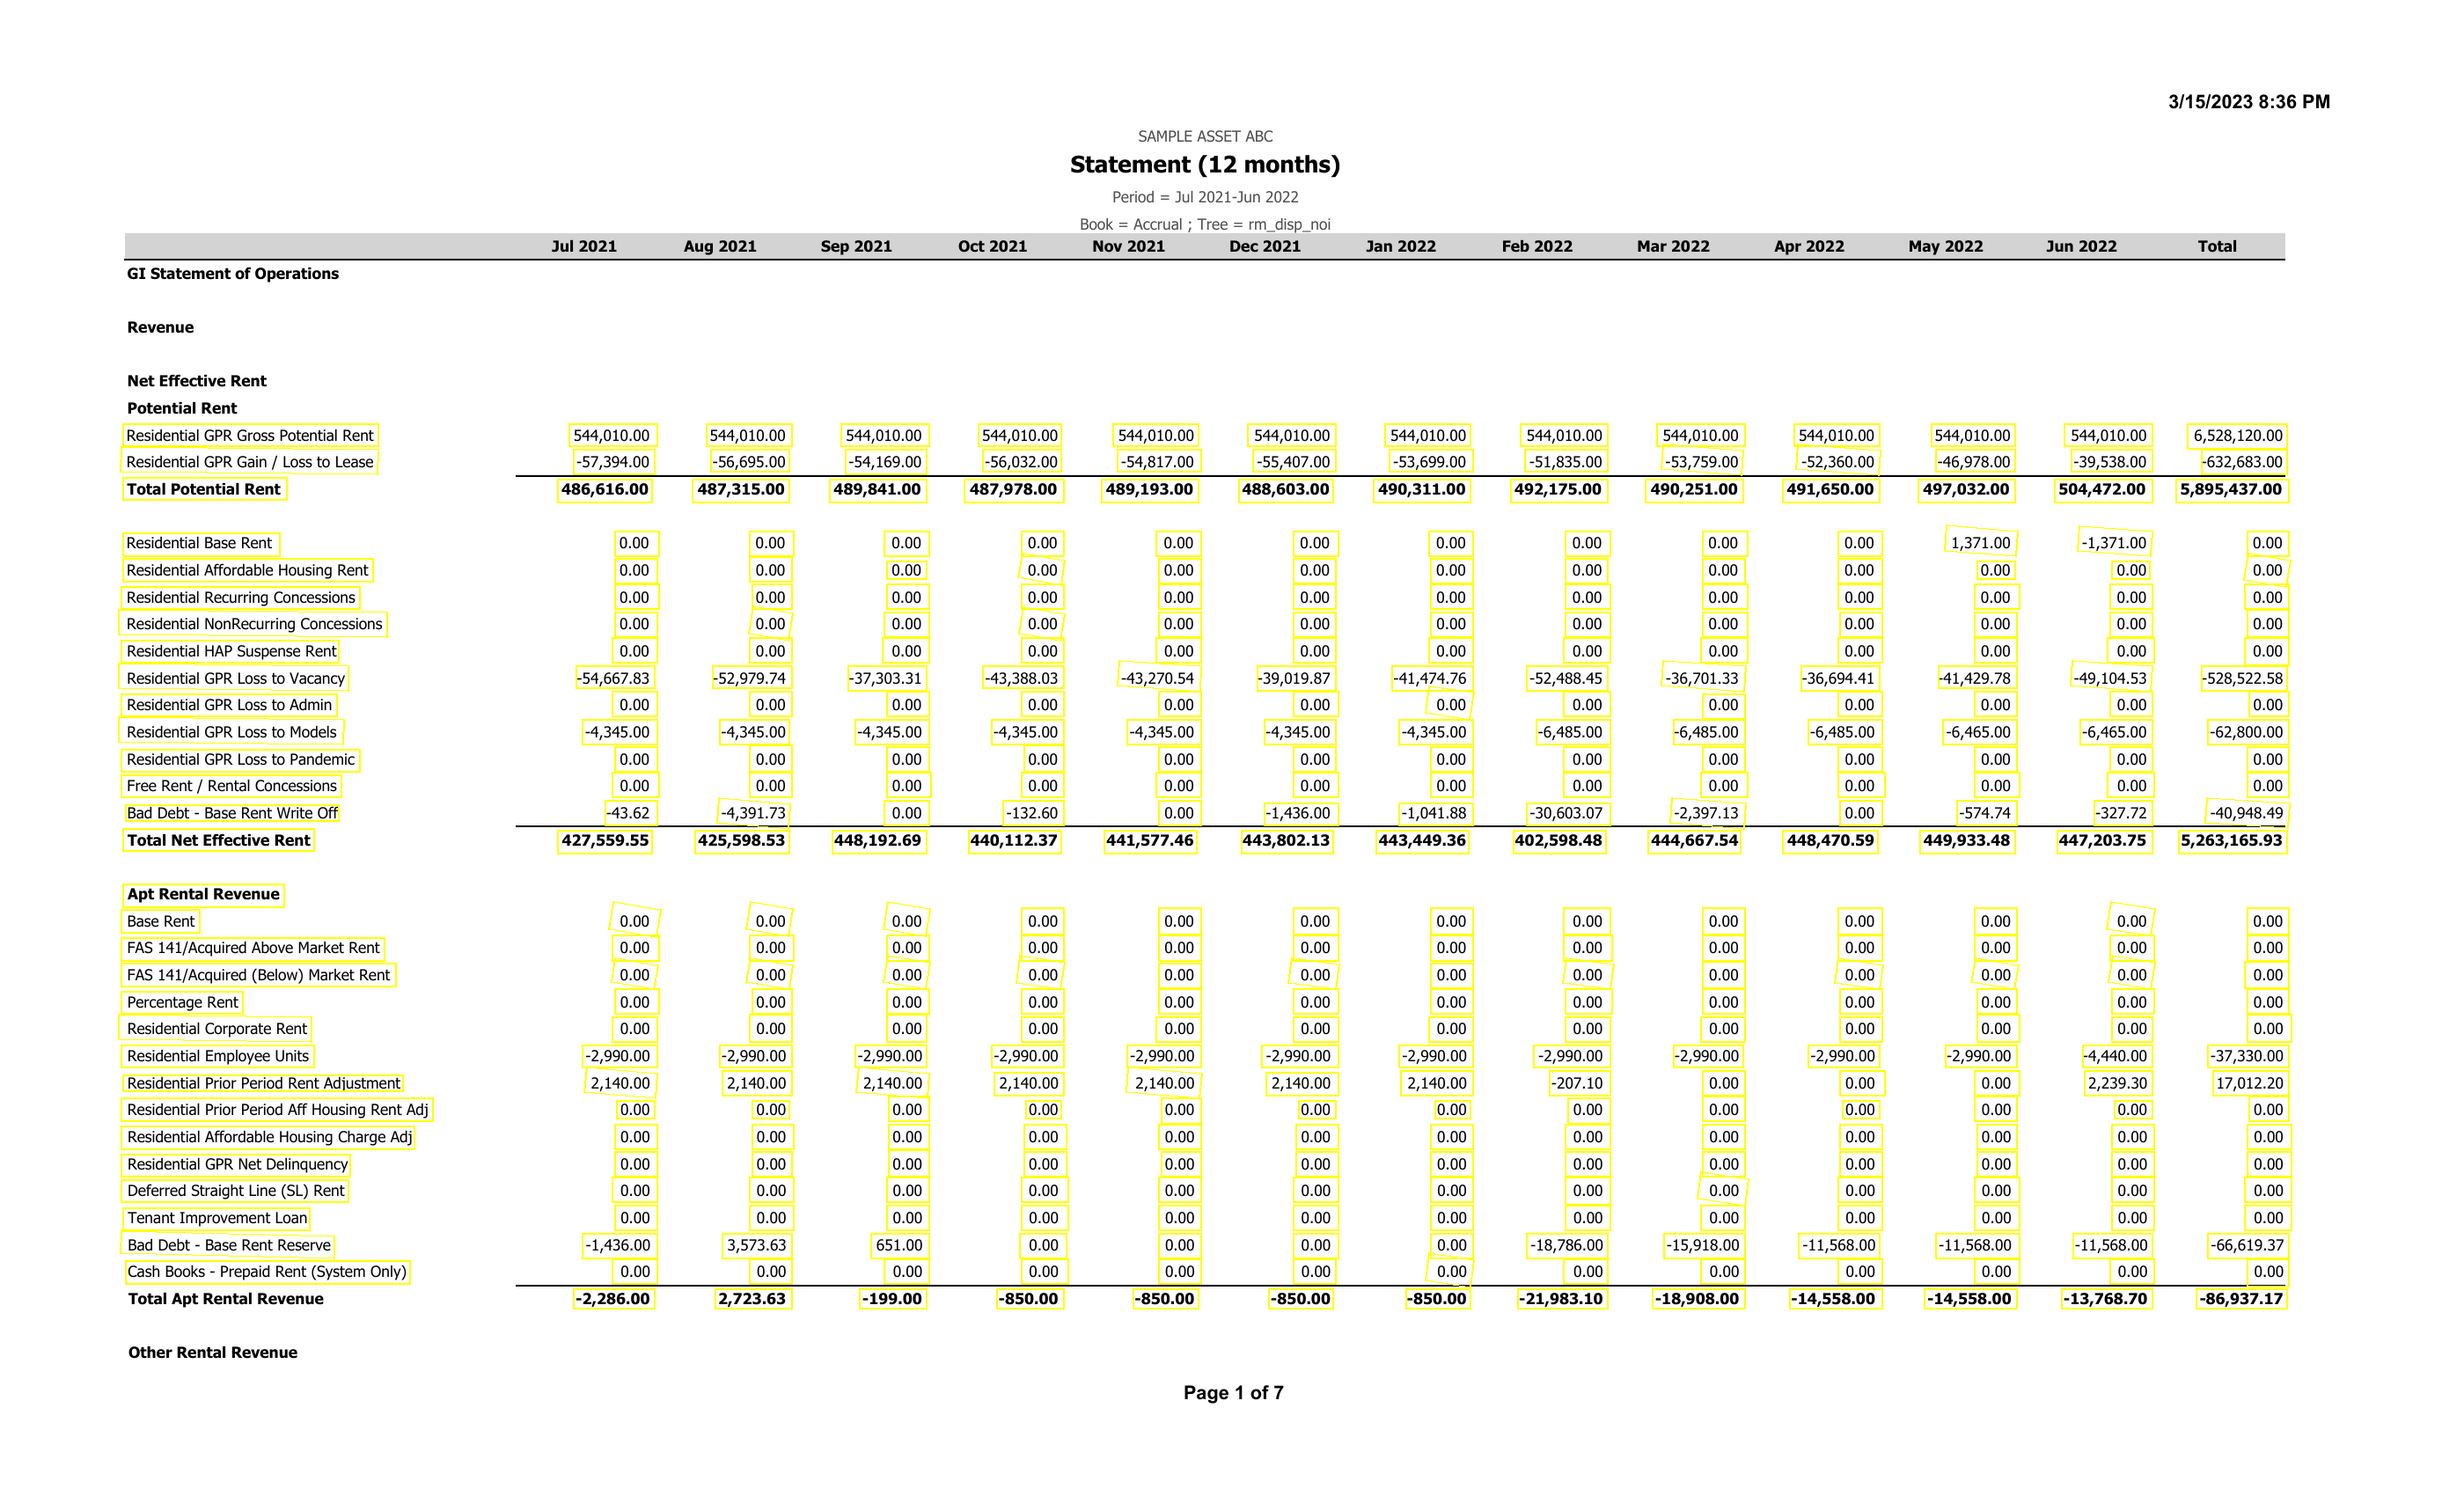

In [ ]:
img

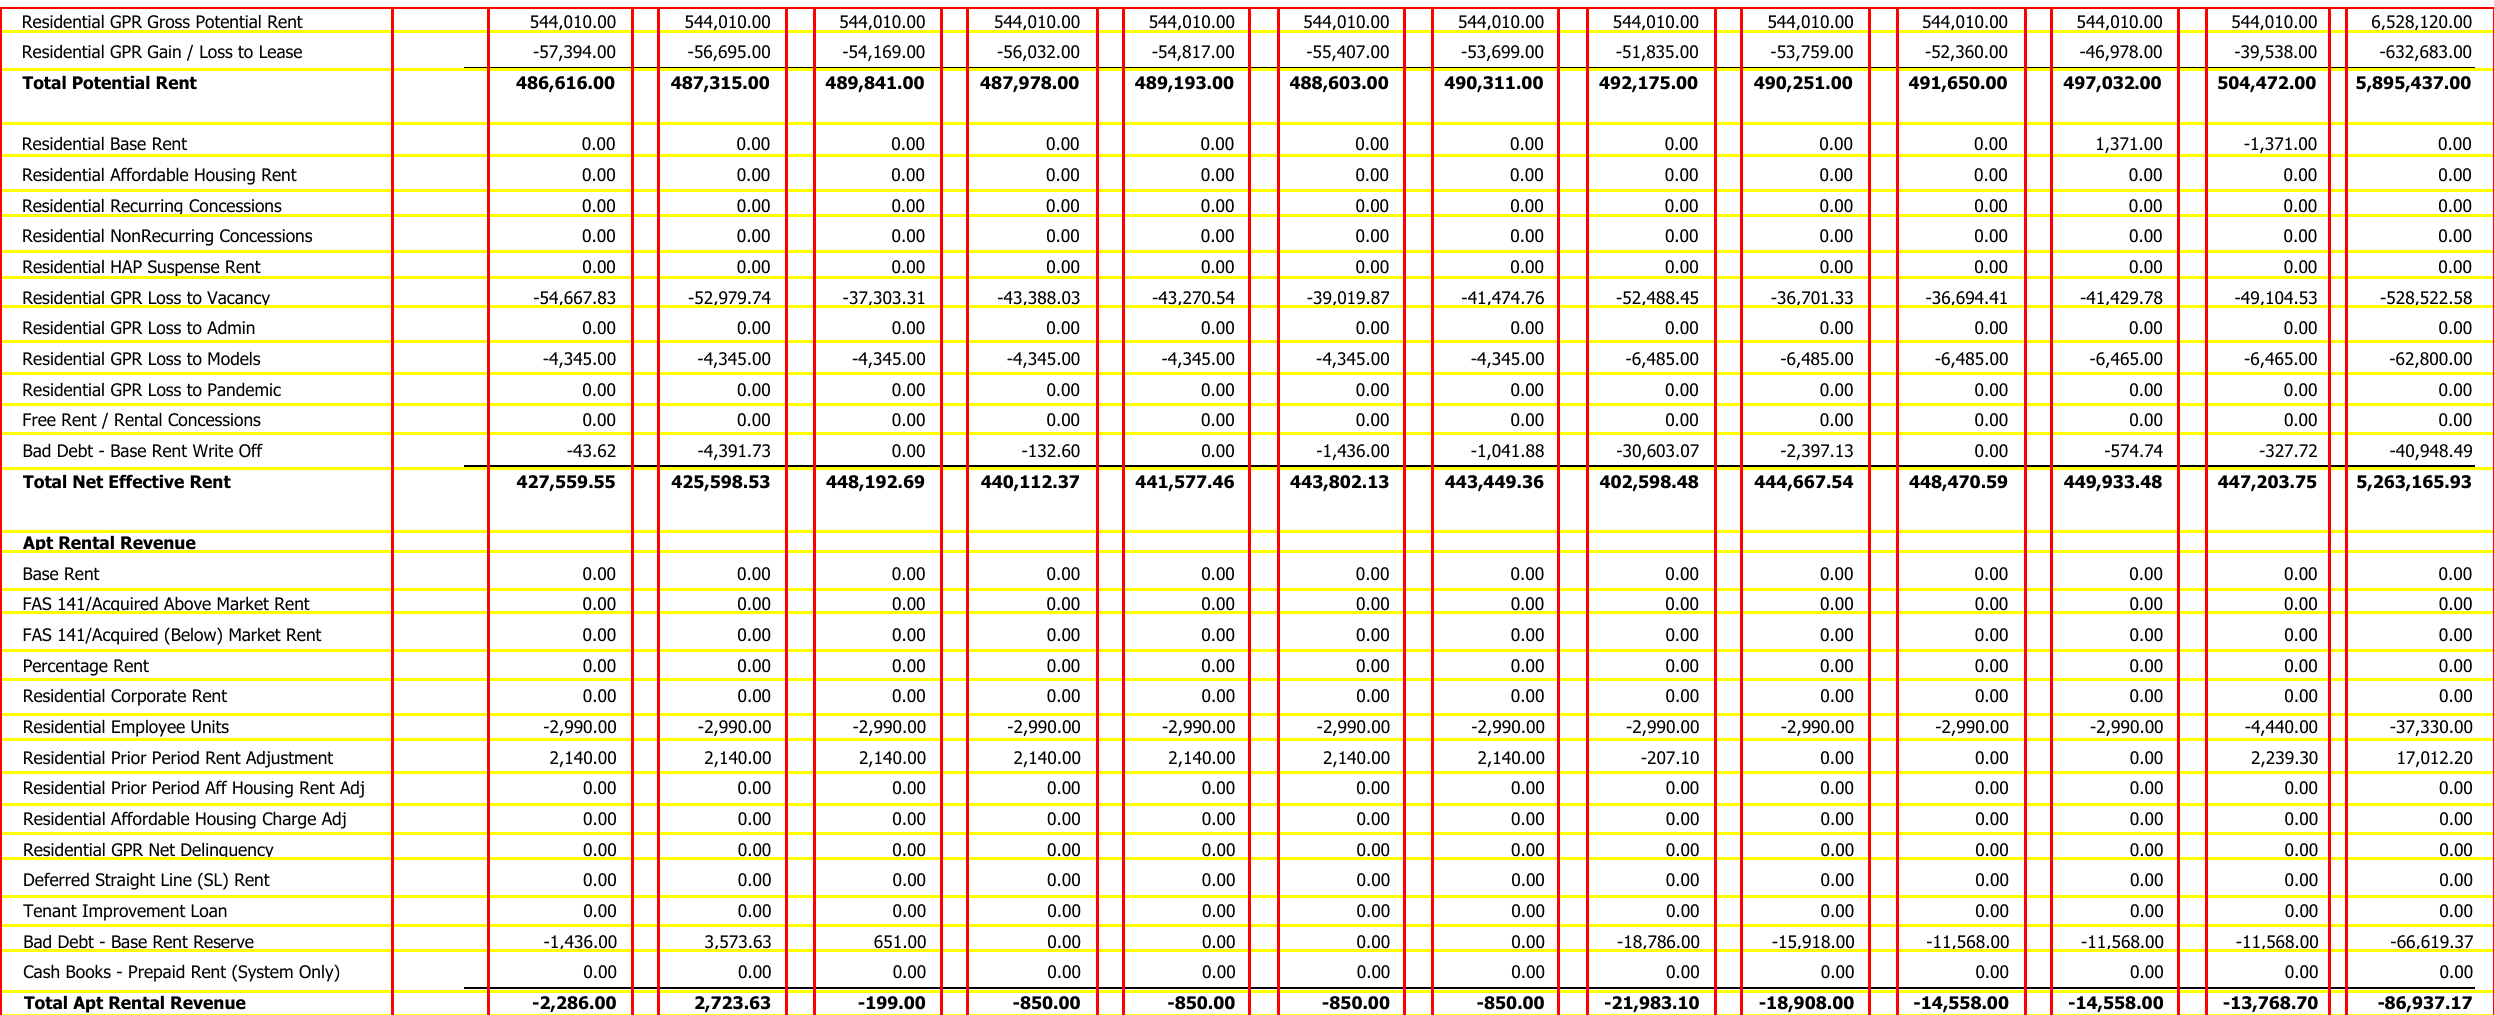

In [ ]:
result['rows'], result['cols'] = detect_row_col_boundary(result['extract_bounds'], result['extracted'])
draw_rows_and_cols(result, colcolor='red', rowcolor="yellow")

Mounted at /content/drive


In [ ]:
table = get_table_structure_detector(result)

In [ ]:
_ = [print(r) for r in table]

['Residential GPR Gross Potential Rent', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '544,010.00', '', '6,528,120.00']
[' Residential GPR Gain / Loss to Lease', '', '-57,394.00', '', '-56,695.00', '', '-54,169.00', '', '-56,032.00', '', '-54,817.00', '', '-55,407.00', '', '-53,699.00', '', '-51,835.00', '', '53,759.00', '', '-52,360.00', '', '-46,978.00', '', '-39,538.00', '', '632,683.00']
['Total Potential Rent', '', '486,616.00', '', '487,315.00', '', '489,841.00', '', '487,978.00', '', '489,193.00', '', '488,603.00', '', '490,311.00', '', '492,175.00', '', '490,251.00', '', '491,650.00', '', '497,032.00', '', '504,472.00', '', '5,895,437.00']
['Residential Base Rent', '', '0.00', '', '0.00', '', '0.00', '', '0.00', '', '0.00', '', '0.00', '', '0.00', '', '0.00', '', '0.00', '', '0.00', '', '1,371.00', '', '-1,371.00', '', '0.0

In [ ]:
for ext_table in extracted_tables:
  print("Extracting table from page no", ext_table['index'] + 1 )
  updated_ext_table = perform_ocr(ext_table)
  updated_ext_table['rows'], updated_ext_table['cols'] = detect_row_col_boundary(updated_ext_table['extract_bounds'], updated_ext_table['extracted'])
  updated_ext_table['table'] = get_table_structure_detector(updated_ext_table)


Extracting table from page no 1


In [ ]:
output_dir = pdf_dir
i = 0
for table in extracted_tables:
  i+=1
  with open(f"{output_dir}/output_{table['index']+1}-{i}.csv", 'w', encoding='UTF8') as f:
      writer = csv.writer(f)
      for r in table['table']:
          writer.writerow(r)

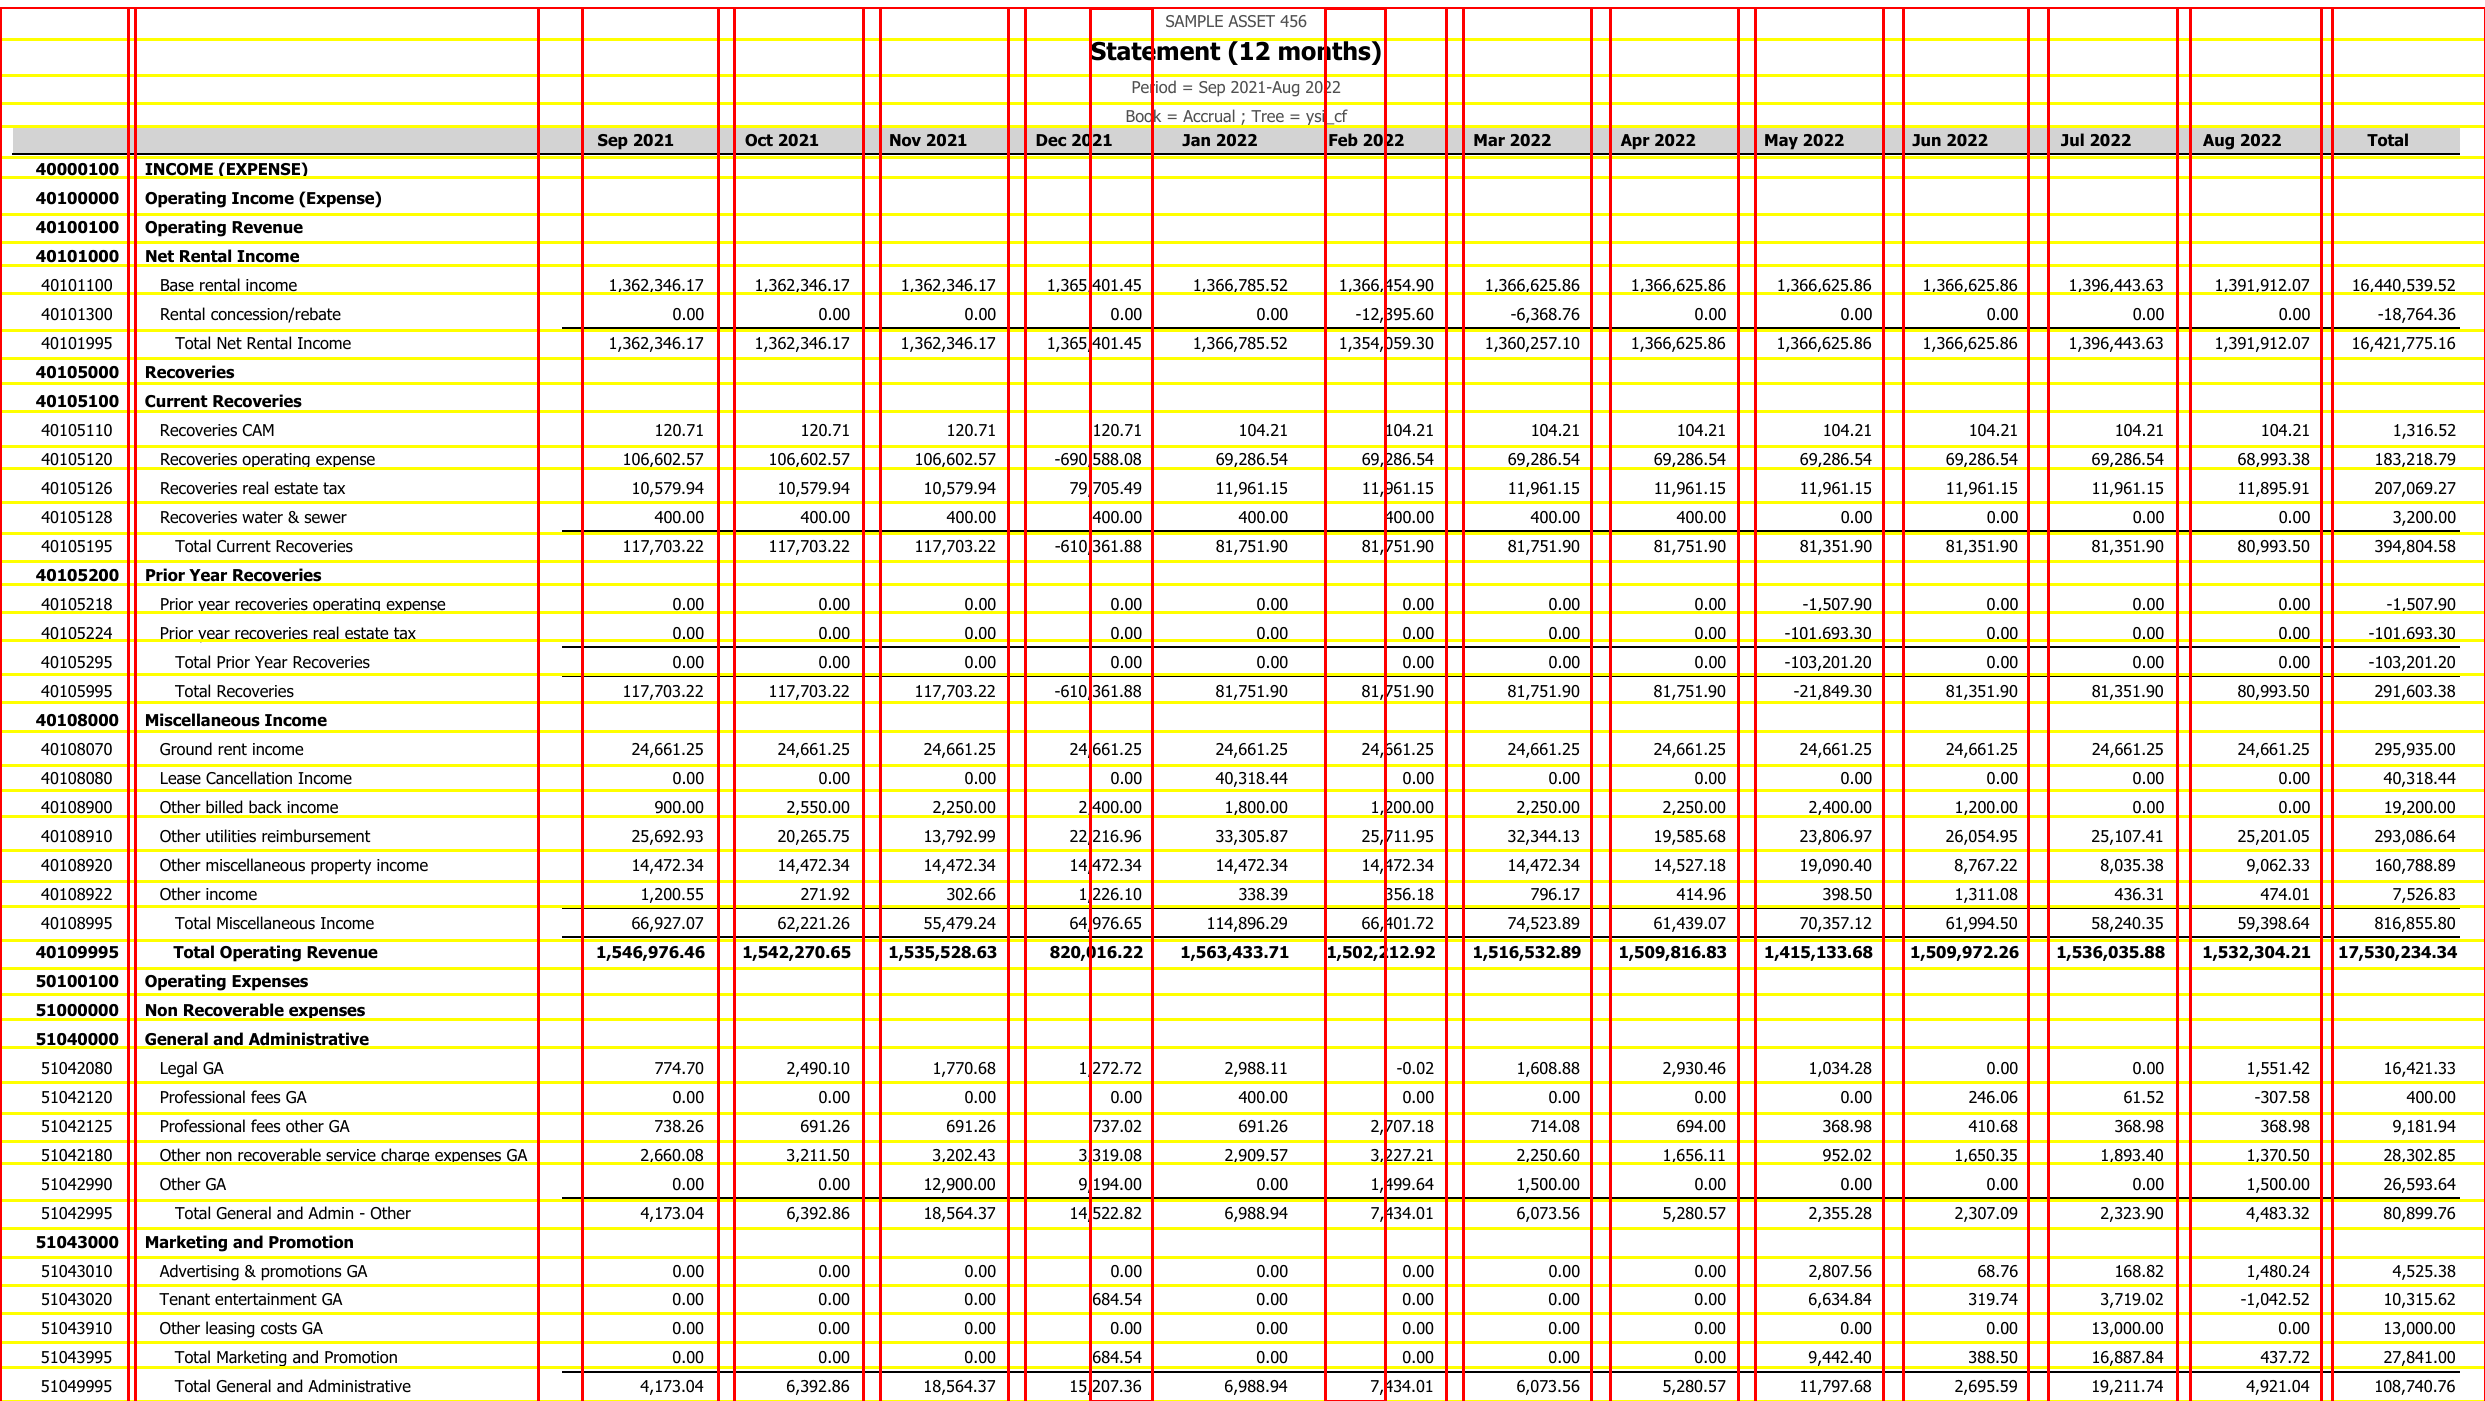

In [ ]:
draw_rows_and_cols(extracted_tables[0], colcolor='red', rowcolor="yellow")

In [ ]:
extracted_tables[0].keys()

dict_keys(['index', 'img', 'extracted', 'box', 'extract_bounds', 'img_bounds', 'rows', 'cols', 'table'])

In [ ]:
_ = [print(r) for r in table]

['', '', '', '', ' Unit', '', '', '', '', '', ' Charge', '', '', '', 'Resident', '', 'Other', '', 'Lease', '', '']
['Unit', '', 'Unit type', '', 'Sq Ft', '', 'Resident', '', 'Name', '', 'Code', '', 'Amount', '', 'Deposit', '', 'Move In', '', 'Move-Out', '', 'Balance']
['Current/Notice Residents', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
['0637', '', '16b2', '', '680', '', 'VACANT', '', 'VACANT', '', '2,992.00', '', '0.00', '', '0.00', '', '0.00', '', '', '', '0.00']
['', '', '', '', '', '', '', '', '', '', 'Total', '', '0.00', '', '', '', '', '', '', '', '']
['0665', '', '16a17', '', '973', '', 'VACANT', '', 'VACANT', '', '2,750.00', '', '0.00', '', '0.00', '', '0.00', '', '', '', '0.00']
['', '', '', '', '', '', '', '', '', '', 'Total', '', '0.00', '', '', '', '', '', '', '', '']
['RETAIL1', '', '16ret1', '', '1,330', '', 'v16ret1', '', 'TENANT 1', '', '4,377.73 cam', '', '1,000.00', '', '7,158.50', '', ' 6/25/2010', '', '4/30/2024', '', '68,423.

In [ ]:
import csv

with open('/content/output_3.csv', 'w', encoding='UTF8') as f:
    writer = csv.writer(f)
    # write the header
    # writer.writerow(h)
    for r in table:
        writer.writerow(r)

In [ ]:
results

[{'scores': tensor([0.9264, 0.8764, 0.6043], grad_fn=<IndexBackward0>),
  'labels': tensor([0, 0, 0]),
  'boxes': tensor([[ 122.0968,  473.4329, 2616.1470, 1488.3817],
          [ 125.8299,  143.9699, 2619.8760, 1504.7145],
          [ 126.7809,  144.9849, 2620.9583,  301.3499]],
         grad_fn=<IndexBackward0>)},
 {'scores': tensor([0.9861], grad_fn=<IndexBackward0>),
  'labels': tensor([0]),
  'boxes': tensor([[ 127.2159,  178.4875, 2612.2544, 1479.3649]],
         grad_fn=<IndexBackward0>)},
 {'scores': tensor([0.9632], grad_fn=<IndexBackward0>),
  'labels': tensor([0]),
  'boxes': tensor([[ 122.3964,  214.9454, 2621.4631, 1598.3953]],
         grad_fn=<IndexBackward0>)},
 {'scores': tensor([0.9852], grad_fn=<IndexBackward0>),
  'labels': tensor([0]),
  'boxes': tensor([[ 124.2453,  190.0190, 2616.7578, 1484.6942]],
         grad_fn=<IndexBackward0>)},
 {'scores': tensor([0.9797], grad_fn=<IndexBackward0>),
  'labels': tensor([0]),
  'boxes': tensor([[ 133.2226,  154.5471, 2604.16